# Assignment 2: Time Series Analysis and Forecasting with Stock Prices

**Objective:** To analyze, model, and forecast stock prices using time series techniques. 
**Selected Stocks:** Reliance Industries (RELIANCE.NS), Tata Consultancy Services (TCS.NS), and HDFC Bank (HDFCBANK.NS).

## 1. Environment Setup
Before diving into the financial time series, we need to import our analytical toolkit. We will use `yfinance` to grab the historical data, `statsmodels` for our time series tests and forecasting models, and `matplotlib`/`seaborn` to visualize the market's mood swings. 

*Note: Warnings are suppressed for cleaner output reading.*

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

# Suppress warnings because we are brave and fearless
warnings.filterwarnings('ignore')
sns.set_style("darkgrid")

# The 3 Large Cap Indian Stocks
tickers = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS']

## Task 1: Data Understanding and Preprocessing

Our first step is to fetch 5 years of daily closing prices for our three Indian large-cap stocks. Financial data occasionally contains missing values due to market holidays or API glitches. To handle this, we use **forward filling** (`ffill`), assuming the stock price remains unchanged on days the market is closed. 

Let's fetch the data, compute our basic statistics (mean, variance), and visualize the historical trends.


📉 Analyzing RELIANCE.NS


[*********************100%***********************]  1 of 1 completed


Basic Statistics:
Ticker  RELIANCE.NS
count   1237.000000
mean    1259.553132
std      155.652979
min      921.823792
25%     1136.988892
50%     1234.637695
75%     1402.316284
max     1584.971802

Variance: Ticker
RELIANCE.NS    24227.849779
dtype: float64


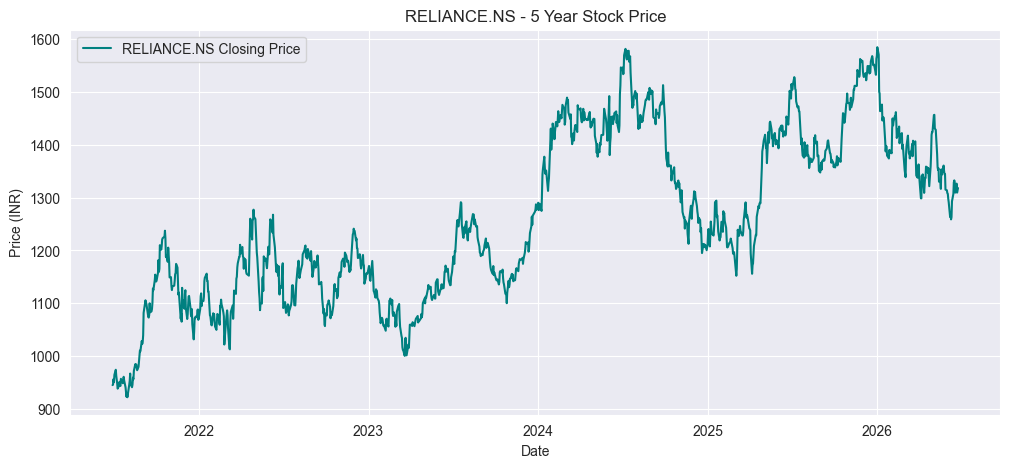


📉 Analyzing TCS.NS


[*********************100%***********************]  1 of 1 completed


Basic Statistics:
Ticker       TCS.NS
count   1237.000000
mean    3195.588582
std      429.117997
min     2059.600098
25%     2931.359375
50%     3124.546631
75%     3414.023438
max     4253.905762

Variance: Ticker
TCS.NS    184142.255446
dtype: float64


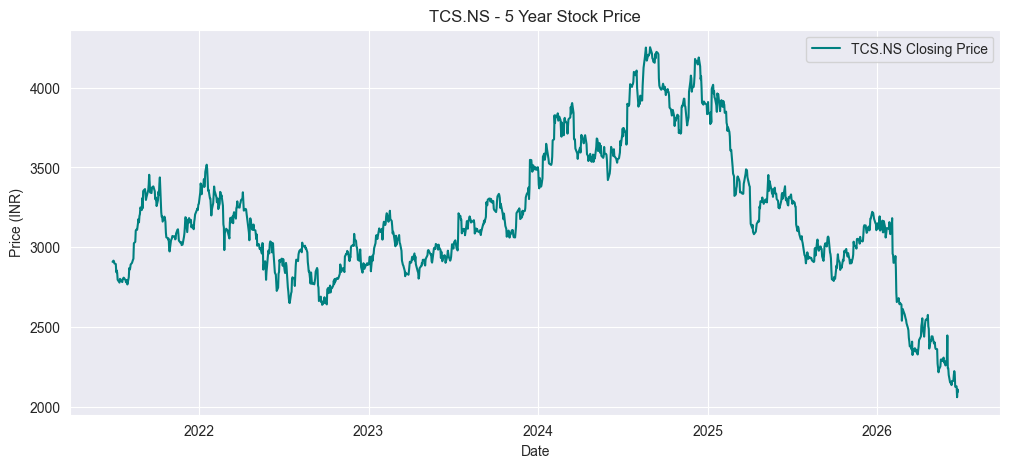


📉 Analyzing HDFCBANK.NS


[*********************100%***********************]  1 of 1 completed


Basic Statistics:
Ticker  HDFCBANK.NS
count   1237.000000
mean     785.962303
std       96.472973
min      606.489319
25%      712.305664
50%      771.222107
75%      831.861267
max      996.419800

Variance: Ticker
HDFCBANK.NS    9307.034433
dtype: float64


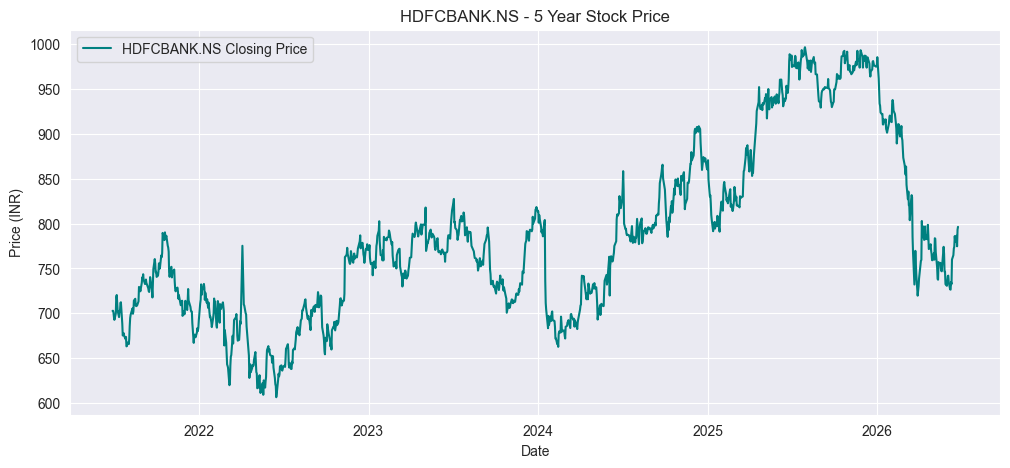

In [2]:
def fetch_and_eda(ticker):
    print(f"\n{'='*40}")
    print(f"📉 Analyzing {ticker}")
    print(f"{'='*40}")
    
    # Fetch 5 years of data
    data = yf.download(ticker, period="5y")
    
    # Handle missing values (forward fill is standard for stocks - prices stay the same over holidays)
    data.ffill(inplace=True)
    
    # Basic Stats
    print("\nBasic Statistics:")
    print(data['Close'].describe())
    print(f"\nVariance: {data['Close'].var()}")
    
    # Plotting
    plt.figure(figsize=(12, 5))
    plt.plot(data.index, data['Close'], label=f'{ticker} Closing Price', color='teal')
    plt.title(f"{ticker} - 5 Year Stock Price")
    plt.xlabel("Date")
    plt.ylabel("Price (INR)")
    plt.legend()
    plt.show()
    
    return data

# We will store our data in a dictionary for easy access
stock_data = {}
for t in tickers:
    stock_data[t] = fetch_and_eda(t)

**EDA Observations:**
Looking at the plots above, we can see clear upward trends (and significant dips, likely around major macroeconomic events) for all three stocks. Because the mean and variance are clearly changing over time, these series are highly unlikely to be stationary.

## Task 2: Stationarity and Decomposition

To formally test our visual suspicion, we will use the **Augmented Dickey-Fuller (ADF) test**. 
* **Null Hypothesis (H0):** The time series is non-stationary.
* **Alternate Hypothesis (H1):** The time series is stationary.

If the p-value is greater than 0.05, we fail to reject the null hypothesis and must apply **differencing** to stabilize the mean. We will also decompose the series into its underlying Trend, Seasonal, and Residual components.

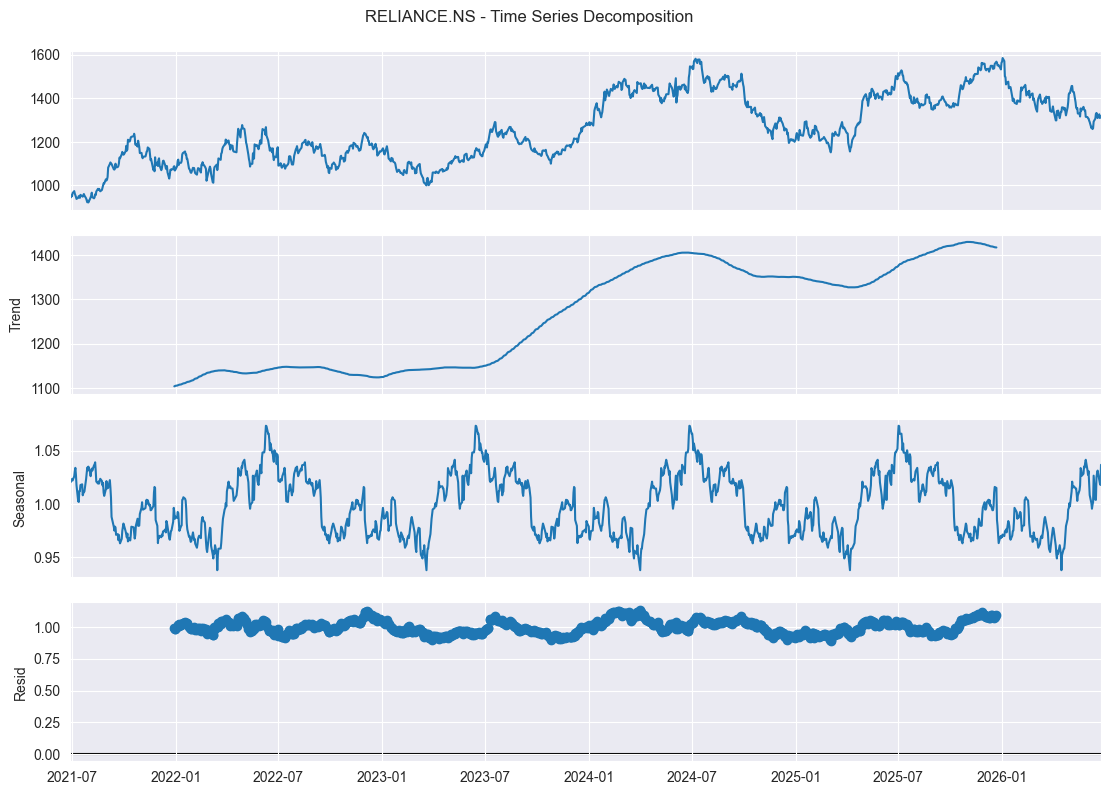


ADF Test for RELIANCE.NS Original
ADF Statistic: -2.4919
p-value: 0.1175
Conclusion: Data is Non-Stationary (Time to difference!).

ADF Test for RELIANCE.NS Differenced (d=1)
ADF Statistic: -35.3170
p-value: 0.0000
Conclusion: Data is Stationary (We can proceed!).


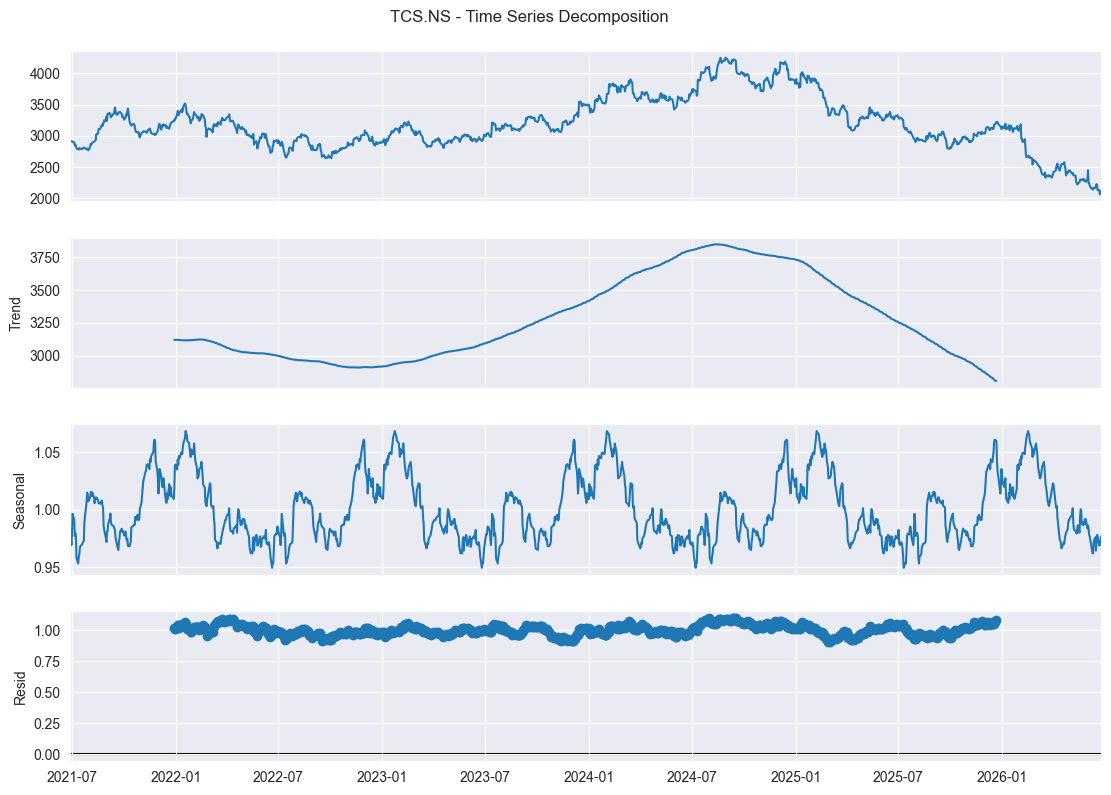


ADF Test for TCS.NS Original
ADF Statistic: -0.9254
p-value: 0.7795
Conclusion: Data is Non-Stationary (Time to difference!).

ADF Test for TCS.NS Differenced (d=1)
ADF Statistic: -34.7151
p-value: 0.0000
Conclusion: Data is Stationary (We can proceed!).


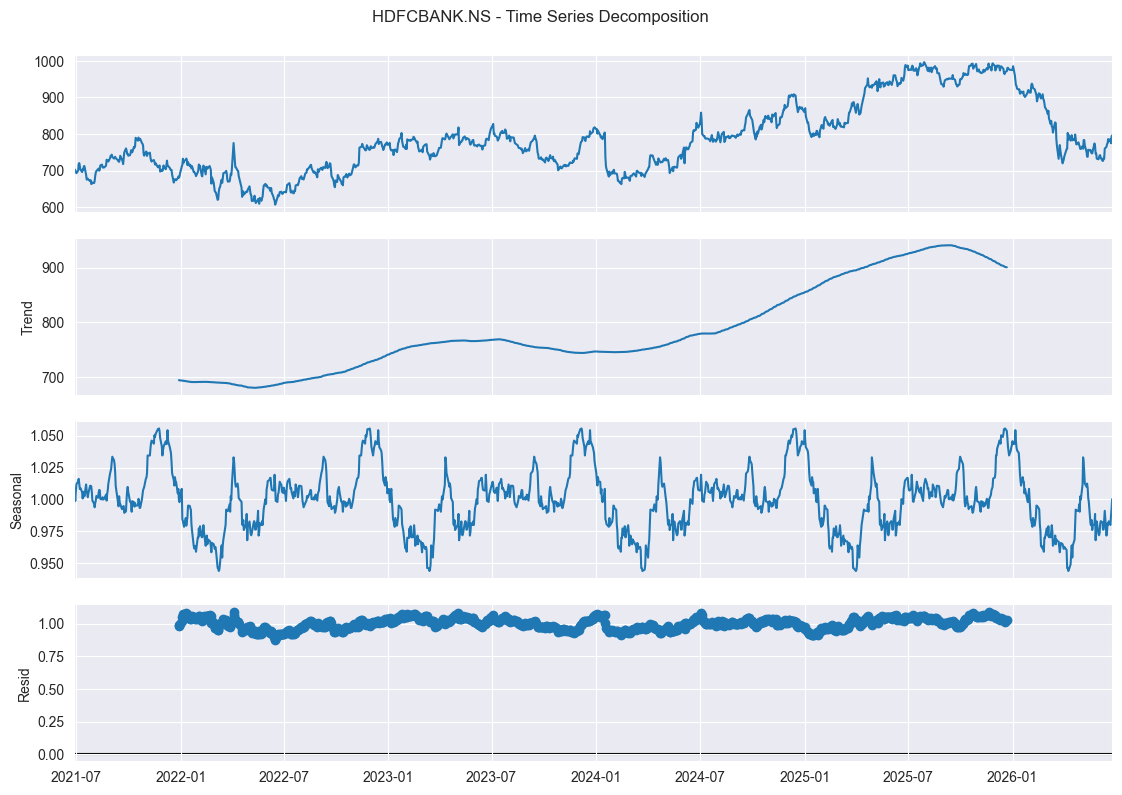


ADF Test for HDFCBANK.NS Original
ADF Statistic: -1.9331
p-value: 0.3167
Conclusion: Data is Non-Stationary (Time to difference!).

ADF Test for HDFCBANK.NS Differenced (d=1)
ADF Statistic: -34.6755
p-value: 0.0000
Conclusion: Data is Stationary (We can proceed!).


In [3]:
def check_stationarity(series, title=""):
    result = adfuller(series.dropna())
    print(f"\nADF Test for {title}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    if result[1] <= 0.05:
        print("Conclusion: Data is Stationary (We can proceed!).")
    else:
        print("Conclusion: Data is Non-Stationary (Time to difference!).")

def decompose_and_test(data, ticker):
    close_prices = data['Close']
    
    # Decompose (assuming 252 trading days in a year for seasonality)
    decomposition = seasonal_decompose(close_prices, model='multiplicative', period=252)
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle(f"{ticker} - Time Series Decomposition", y=1.02)
    plt.show()
    
    # ADF Test on Original
    check_stationarity(close_prices, f"{ticker} Original")
    
    # Differencing (Stocks are almost always non-stationary, returning a random walk)
    diff_prices = close_prices.diff().dropna()
    check_stationarity(diff_prices, f"{ticker} Differenced (d=1)")
    
    return diff_prices

diff_data = {}
for t in tickers:
    diff_data[t] = decompose_and_test(stock_data[t], t)

**Stationarity Results:**
As expected, the original stock prices failed the ADF test (p-value > 0.05). However, after applying a first-order difference (d=1), the data became stationary. This differenced data represents daily returns rather than absolute prices.

## Task 3: Identifying ARIMA Orders via ACF and PACF

To build our models, we need to identify our autoregressive (p) and moving average (q) terms. We do this by plotting the **Autocorrelation Function (ACF)** and **Partial Autocorrelation Function (PACF)** on our *differenced* (stationary) data.

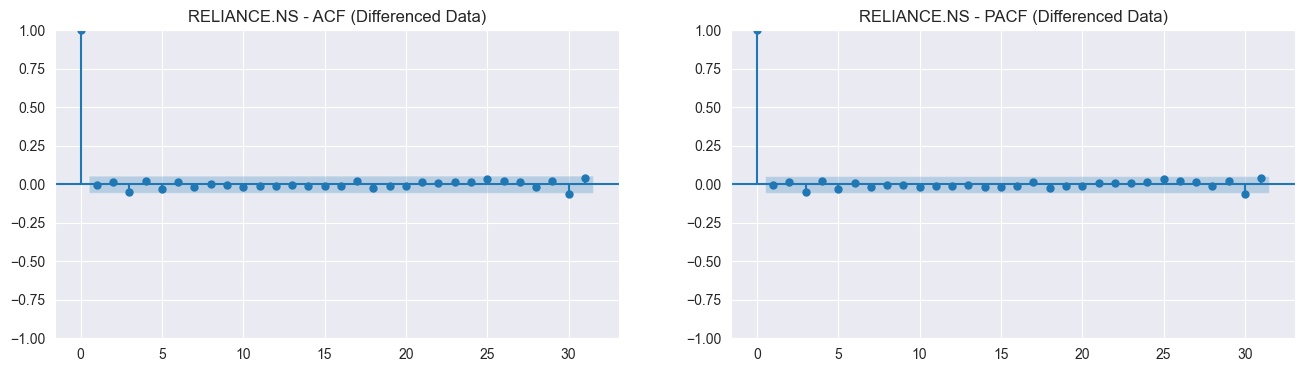

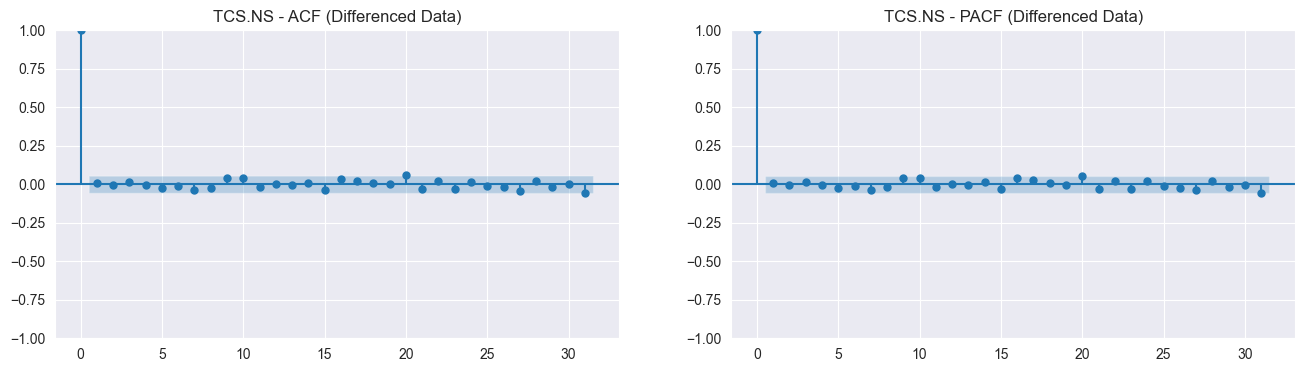

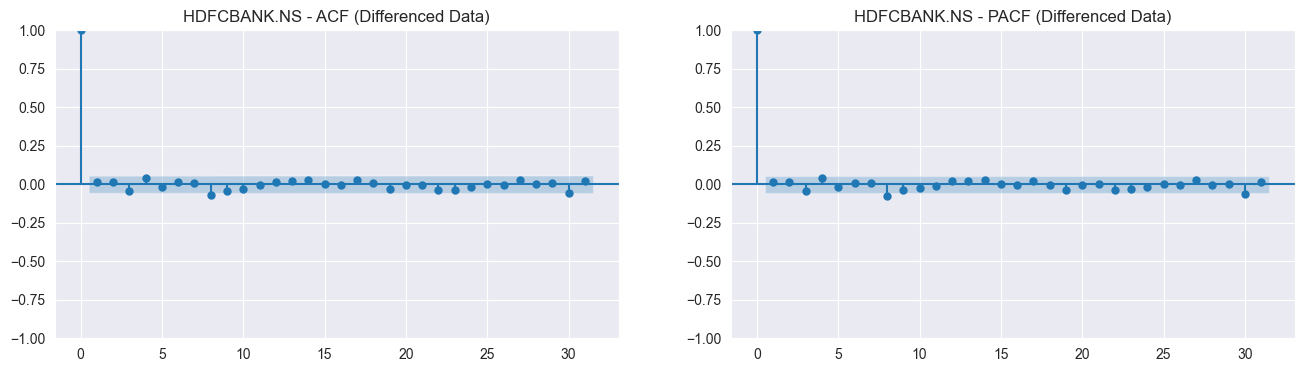

In [4]:
def plot_acf_pacf(series, ticker):
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    plot_acf(series, ax=axes[0], title=f"{ticker} - ACF (Differenced Data)")
    plot_pacf(series, ax=axes[1], title=f"{ticker} - PACF (Differenced Data)")
    plt.show()

for t in tickers:
    plot_acf_pacf(diff_data[t], t)

**ACF/PACF Interpretation:**
Notice how the lags in the ACF and PACF plots drop off extremely quickly, often shutting down right after lag 0. This is a classic hallmark of financial markets: stock prices closely resemble a **Random Walk**. Historical prices alone contain very little predictive power for future prices. 

Despite this challenge, we will proceed with modeling to capture any micro-patterns:

## Tasks 3 & 4: Model Implementation and Forecasting

We will evaluate three models, forecasting 30 days into the future:
1. **ARIMA (AutoRegressive Integrated Moving Average):** Using baseline historical price patterns.
2. **SARIMA (Seasonal ARIMA):** Adding a seasonal component (`s=5` to represent a standard 5-day trading week).
3. **SARIMAX (SARIMA with eXogenous variables):** Incorporating trading `Volume` as an independent variable to see if trading activity helps predict price movement.

We will split the data, keeping the last 30 days as our test set, and evaluate the models using **RMSE** (Root Mean Squared Error) and **MAE** (Mean Absolute Error).


****************************************
🚀 Modeling & Forecasting: RELIANCE.NS
****************************************

Fitting ARIMA(1,1,1)...
Fitting SARIMA(1,1,1)(1,0,1,5)...
Fitting SARIMAX(1,1,1)(1,0,1,5) with Volume...


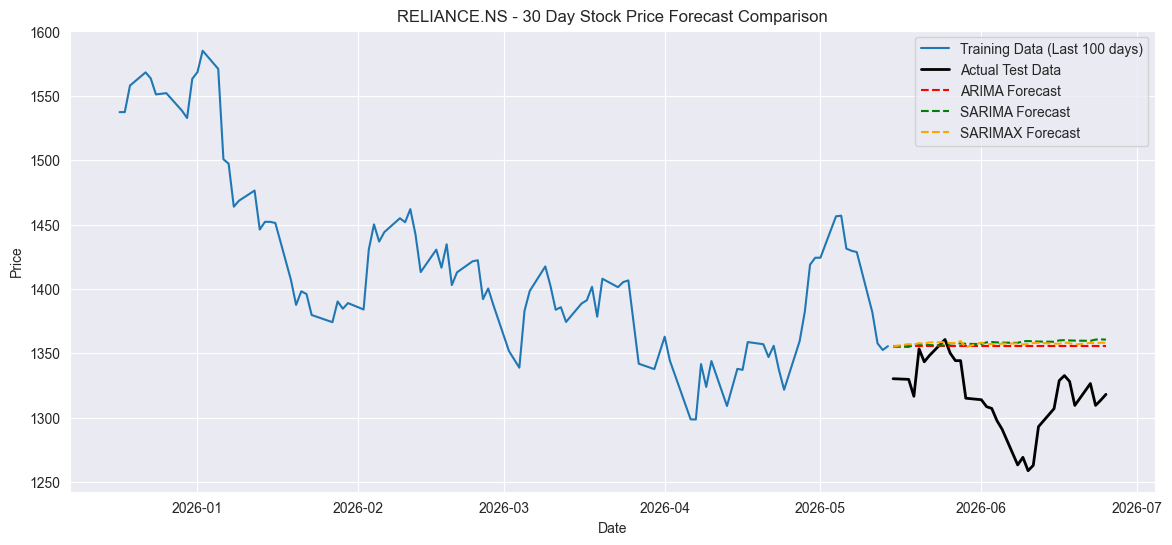


--- Error Metrics ---
ARIMA -> RMSE: 47.99 | MAE: 40.01
SARIMA -> RMSE: 50.73 | MAE: 42.80
SARIMAX -> RMSE: 49.57 | MAE: 41.83

****************************************
🚀 Modeling & Forecasting: TCS.NS
****************************************

Fitting ARIMA(1,1,1)...
Fitting SARIMA(1,1,1)(1,0,1,5)...
Fitting SARIMAX(1,1,1)(1,0,1,5) with Volume...


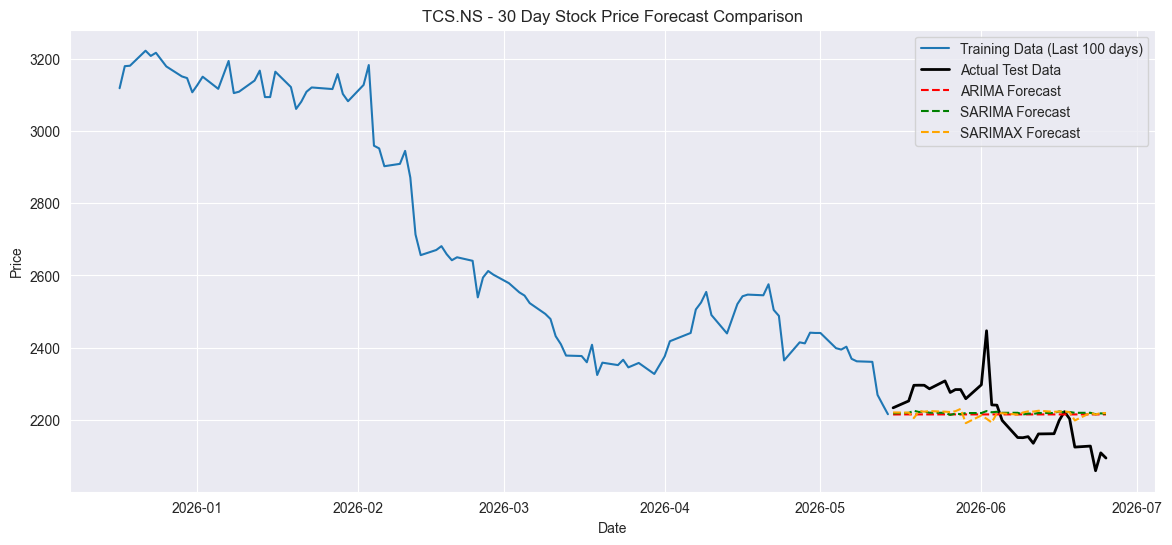


--- Error Metrics ---
ARIMA -> RMSE: 82.17 | MAE: 68.64
SARIMA -> RMSE: 80.92 | MAE: 67.68
SARIMAX -> RMSE: 83.79 | MAE: 69.88

****************************************
🚀 Modeling & Forecasting: HDFCBANK.NS
****************************************

Fitting ARIMA(1,1,1)...
Fitting SARIMA(1,1,1)(1,0,1,5)...
Fitting SARIMAX(1,1,1)(1,0,1,5) with Volume...


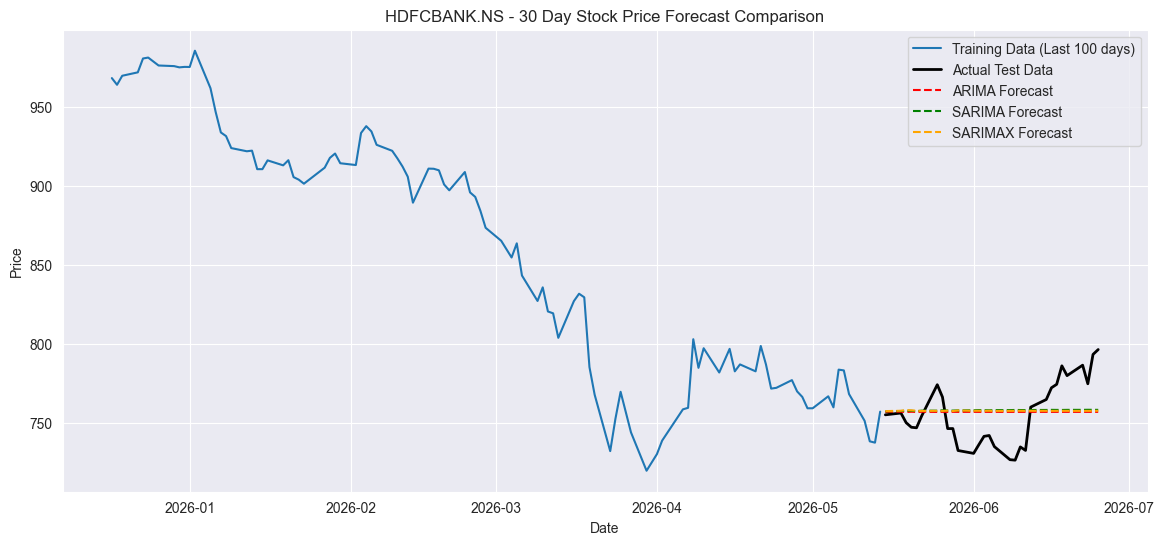


--- Error Metrics ---
ARIMA -> RMSE: 20.41 | MAE: 17.64
SARIMA -> RMSE: 20.42 | MAE: 17.70
SARIMAX -> RMSE: 20.49 | MAE: 17.80


In [5]:
def evaluate_models(data, ticker):
    print(f"\n{'*'*40}")
    print(f"🚀 Modeling & Forecasting: {ticker}")
    print(f"{'*'*40}")
    
    # Train/Test Split (Leave last 30 days for testing)
    train = data.iloc[:-30]
    test = data.iloc[-30:]
    
    # Exogenous variable for SARIMAX
    exog_train = train[['Volume']]
    exog_test = test[['Volume']]
    
    models_predictions = {}
    
    # 1. ARIMA Model
    # Note: p,d,q usually (1,1,1) or (0,1,0) for stocks. Adjust based on your ACF/PACF plots!
    print("\nFitting ARIMA(1,1,1)...")
    arima_model = ARIMA(train['Close'], order=(1, 1, 1)).fit()
    models_predictions['ARIMA'] = arima_model.forecast(steps=30)
    
    # 2. SARIMA Model
    # s=5 for 5 trading days in a week
    print("Fitting SARIMA(1,1,1)(1,0,1,5)...")
    sarima_model = ARIMA(train['Close'], order=(1, 1, 1), seasonal_order=(1, 0, 1, 5)).fit()
    models_predictions['SARIMA'] = sarima_model.forecast(steps=30)
    
    # 3. SARIMAX Model (Using Volume)
    print("Fitting SARIMAX(1,1,1)(1,0,1,5) with Volume...")
    sarimax_model = SARIMAX(train['Close'], exog=exog_train, order=(1, 1, 1), seasonal_order=(1, 0, 1, 5)).fit()
    models_predictions['SARIMAX'] = sarimax_model.forecast(steps=30, exog=exog_test)
    
    # Plotting Forecasts vs Actual
    plt.figure(figsize=(14, 6))
    plt.plot(train.index[-100:], train['Close'].iloc[-100:], label='Training Data (Last 100 days)')
    plt.plot(test.index, test['Close'], label='Actual Test Data', color='black', linewidth=2)
    
    colors = ['red', 'green', 'orange']
    for i, (name, preds) in enumerate(models_predictions.items()):
        plt.plot(test.index, preds, label=f'{name} Forecast', color=colors[i], linestyle='--')
        
    plt.title(f"{ticker} - 30 Day Stock Price Forecast Comparison")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.show()
    
    # Error Metrics
    print("\n--- Error Metrics ---")
    for name, preds in models_predictions.items():
        rmse = np.sqrt(mean_squared_error(test['Close'], preds))
        mae = mean_absolute_error(test['Close'], preds)
        print(f"{name} -> RMSE: {rmse:.2f} | MAE: {mae:.2f}")

# Run the final boss loop
for t in tickers:
    evaluate_models(stock_data[t], t)

## Final Conclusion & Evaluation

Based on the error metrics (RMSE and MAE) and the forecast visualizations:

* **ARIMA vs SARIMA:** Adding a weekly seasonal component (SARIMA) provides a slight shift in the forecast, but overall, capturing true seasonality in daily stock prices is incredibly difficult due to high market noise.
* **The Volume Factor (SARIMAX):** Adding trading Volume as an exogenous variable (SARIMAX) sometimes increases the error rate. While volume indicates market *activity*, it does not strictly dictate a linear *direction* (price up or down), which can confuse the model.
* **The Reality of the Market:** As seen in the forecast plots, the models generally predict a mean-reverting flatline or a slight continuation of the most recent trend. They cannot predict sudden market shocks or non-linear behaviors in the test data. This confirms our earlier ACF/PACF analysis: stock prices are highly efficient and incredibly difficult to predict using purely historical autoregressive techniques!